In [1]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, welch
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
from scipy.stats import linregress, spearmanr
import re
from scipy.stats import shapiro
import scipy.stats as stats
from numpy.polynomial.polynomial import Polynomial

In [2]:
input_folder = "Combined Data 60dB"

In [3]:
# --- Filter functions ---
nperseg = 1024 
noverlap = nperseg // 2

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


def butter_bandstop(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandstop')
    return b, a


def apply_filters(signal, fs):
    # Ensure numeric array (coerce bad strings to NaN, then interpolate/zero-fill)
    signal = pd.to_numeric(np.asarray(signal).ravel(), errors='coerce').astype(np.float64)
    if not np.isfinite(signal).all():
        signal = pd.Series(signal).interpolate(limit_direction='both').fillna(0.0).to_numpy()


    # Bandpass 1-120 Hz
    b_bp, a_bp = butter_bandpass(1.0, 120.0, fs, 4)
    filtered = filtfilt(b_bp, a_bp, signal)
    # Notch 40-55 Hz
    b_notch, a_notch = butter_bandstop(40.0, 55.0, fs, 1)
    filtered = filtfilt(b_notch, a_notch, filtered)
    # Smoothing (moving average, 5 ms window)
    window_size = max(1, int(fs * (5 / 1000.0)))
    filtered = uniform_filter1d(filtered, size=window_size)
    return filtered


In [4]:
files = [f for f in os.listdir(input_folder) if f.lower().endswith(".csv")] 

# Dictionaries for different trial types
ppi_values = {}  # For capitalized OFFSET trials (dual recordings)
max_values = {}  # For non-offset/control trials
offset_ppi_trials = {}  # For offset_PPI_X and TIN_X trials (separate recordings)
asr_control_trials = {}  # For ASR control trials
repetition_tracker = {}

for filename in files:
    filepath = os.path.join(input_folder, filename)
    
    # Load CSV and skip nonsensical rows
    df = pd.read_csv(filepath, low_memory=False, skiprows=[0, 2])

    # Extract animal number and date from filename
    animal_number = filename[:-4].split('_')[0]
    date = filename[:-4].split('_')[1]
    animal_date_key = f"{animal_number}_{date}"

    # Convert value column to numeric
    df.iloc[:, 19] = pd.to_numeric(df.iloc[:, 19], errors='coerce')
    signal = df.iloc[:, 19].values
    
    # Apply filters
    filtered_signal = apply_filters(signal, 500.0)

    # Take absolute value after filtering 
    filtered_signal = np.abs(filtered_signal)
    df.iloc[:, 19] = filtered_signal
    
    # Get Trial column (column 17, 1-indexed = index 16)
    df['trial'] = df.iloc[:, 16].astype(str).str.strip()
    
    # Filter for rows containing 'control', 'offset', or 'tin' (case-insensitive)
    df['is_target'] = df['trial'].str.lower().str.contains('control|offset|tin', na=False)
    df = df[df['is_target']].copy()
    
    if len(df) == 0:
        continue
    
    # Identify segments (consecutive rows with same trial name)
    df['trial_shift'] = df['trial'].shift(1)
    df['new_segment'] = df['trial'] != df['trial_shift']
    df['segment_id'] = df['new_segment'].cumsum()
    
    # Process each segment
    for segment_id, segment_df in df.groupby('segment_id'):
        trial_name = segment_df.iloc[0]['trial']
        trial_name_lower = str(trial_name).lower()
        
        # Create unique key for this animal+trial combination
        animal_trial_key = f"{animal_number}_{trial_name}"
        
        # Increment repetition counter
        if animal_trial_key not in repetition_tracker:
            repetition_tracker[animal_trial_key] = 0
        repetition_tracker[animal_trial_key] += 1
        
        unique_key = f"{animal_number}_{trial_name}_Rep{repetition_tracker[animal_trial_key]}"
        
        # Get max value for this segment
        max_val = segment_df.iloc[:, 19].max()
        
        # Check if this is a capitalized OFFSET trial (dual recording with split)
        if 'offset' in trial_name_lower and 'offset_ppi' not in trial_name_lower and 'tin' not in trial_name_lower:
            # Split at MS = 15000 (column 18, 0-indexed)
            segment_df['MS'] = pd.to_numeric(segment_df.iloc[:, 18], errors='coerce')
            split_idx = segment_df[segment_df['MS'] >= 15000].index
            
            if len(split_idx) > 0:
                # First segment: prepulse+startle (PPS)
                first_half = segment_df.loc[:split_idx[0]-1]
                # Second segment: startle alone (S)
                second_half = segment_df.loc[split_idx[0]:]
                
                if len(first_half) > 0 and len(second_half) > 0:
                    PPS = first_half.iloc[:, 19].max()
                    S = second_half.iloc[:, 19].max()
                    
                    # Calculate %PPI = 100 * ((S - PPS) / S)
                    if S != 0:
                        ppi_percent = 100 * ((S - PPS) / S)
                        ppi_values[unique_key] = ppi_percent
                    else:
                        ppi_values[unique_key] = np.nan
                else:
                    ppi_values[unique_key] = max_val
            else:
                ppi_values[unique_key] = max_val
        
        # Check if this is offset_PPI_X trial (separate recording)
        elif 'offset_ppi' in trial_name_lower:
            # Store with animal_date_trial key
            trial_type_match = re.search(r'offset_ppi[_\s-]*(\d+|old)\b', trial_name, flags=re.IGNORECASE)
            if trial_type_match:
                suffix = trial_type_match.group(1)
                if str(suffix).lower() == 'old':
                    trial_type = 'offset_PPI_old'
                else:
                    trial_type = f"offset_PPI_{int(suffix)}"
            else:
                trial_type = trial_name
            
            key = f"{animal_date_key}_{trial_type}"
            if key not in offset_ppi_trials:
                offset_ppi_trials[key] = []
            offset_ppi_trials[key].append(max_val)
        
        # Check if this is a TIN trial (TIN_X variants, including TIN_old)
        elif 'tin' in trial_name_lower:
            tin_match = re.search(r'tin[_\s-]*(\d+|old)\b', trial_name, flags=re.IGNORECASE)
            if tin_match:
                tin_suffix = tin_match.group(1)
                if tin_suffix.lower() == 'old':
                    trial_type = 'TIN_old'
                else:
                    trial_type = f"TIN_{int(tin_suffix)}"
            else:
                trial_type = trial_name
            
            key = f"{animal_date_key}_{trial_type}"
            if key not in offset_ppi_trials:
                offset_ppi_trials[key] = []
            offset_ppi_trials[key].append(max_val)
        
        # Check if this is an ASR control trial
        elif 'control' in trial_name_lower and 'asr' in trial_name_lower:
            key = animal_date_key
            if key not in asr_control_trials:
                asr_control_trials[key] = []
            asr_control_trials[key].append(max_val)
        
        else:
            # Other trials - just save the maximum
            max_values[unique_key] = max_val

# Calculate %PPI for offset_PPI and TIN trials by comparing to ASR controls
# Track matching statistics
matched_count = 0
unmatched_count = 0
unmatched_trials = []

print("\n" + "="*70)
print("MATCHING offset_PPI/TIN TRIALS WITH ASR CONTROLS (same animal & date)")
print("="*70)

for offset_key, offset_values in offset_ppi_trials.items():
    # Extract animal_date and trial type
    parts = offset_key.split('_')
    animal = parts[0]
    date = parts[1]
    trial_type = '_'.join(parts[2:])  # e.g., "offset_PPI_10" or "TIN_10"
    animal_date_key = f"{animal}_{date}"
    
    # Get corresponding ASR control values
    if animal_date_key in asr_control_trials:
        # Average across repetitions (within the same date)
        avg_offset = np.mean(offset_values)
        avg_control = np.mean(asr_control_trials[animal_date_key])
        
        # Calculate %PPI = 100 * ((S_control - PPS_offset) / S_control)
        if avg_control != 0:
            ppi_percent = 100 * ((avg_control - avg_offset) / avg_control)
            # Store with descriptive key including date
            ppi_key = f"{animal}_{date}_{trial_type}"
            ppi_values[ppi_key] = ppi_percent
            matched_count += 1
            
            print(f"✓ {animal} {date} {trial_type}: matched with {len(asr_control_trials[animal_date_key])} ASR control(s)")
        else:
            print(f"⚠ {animal} {date} {trial_type}: ASR control = 0, skipping")
            unmatched_count += 1
            unmatched_trials.append(offset_key)
    else:
        print(f"✗ {animal} {date} {trial_type}: NO MATCHING ASR CONTROL FOUND")
        unmatched_count += 1
        unmatched_trials.append(offset_key)

print("\n" + "="*70)
print(f"MATCHING SUMMARY:")
print(f"  Successfully matched: {matched_count}")
print(f"  Unmatched/skipped:    {unmatched_count}")
print("="*70)

if unmatched_trials:
    print("\nWARNING: The following offset_PPI/TIN trials had no matching ASR controls:")
    for trial in unmatched_trials:
        print(f"  - {trial}")

print(f"\nProcessed {len(ppi_values)} %PPI values ({sum(1 for k in ppi_values.keys() if ('offset_PPI' in k or 'TIN_' in k))} from offset_PPI/TIN trials).")
print(f"Processed {len(max_values)} other trial segments.")

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'Combined Data 60dB'

In [ ]:
# Convert to DataFrames
ppi_df = pd.DataFrame(list(ppi_values.items()), columns=['Key', '%PPI'])
max_df = pd.DataFrame(list(max_values.items()), columns=['Key', 'Max_ValueG'])

print("\nSample %PPI entries:")
print(ppi_df.head())
print("\nSample Max Value entries:")
print(max_df.head())

# Calculate mean %PPI per trial
# Extract trial name from key (format varies: Animal_Trial_RepN for OFFSET trials, Animal_offset_PPI_X/TIN_X for matched trials)
def extract_trial_name(key):
    # Handle matched offset_PPI trials (format: Animal_Date_offset_PPI_X)
    if 'offset_PPI' in key:
        match = re.search(r'(offset_PPI_\d+)', key, flags=re.IGNORECASE)
        if match:
            return match.group(1)
        return key

    # Handle matched TIN trials (format: Animal_Date_TIN_X or Animal_Date_TIN_old)
    if re.search(r'\bTIN\b', key, flags=re.IGNORECASE):
        match = re.search(r'(TIN_(?:\d+|old))', key, flags=re.IGNORECASE)
        if match:
            tin_val = match.group(1)
            if tin_val.lower() == 'tin_old':
                return 'TIN_old'
            num_match = re.search(r'\d+', tin_val)
            if num_match:
                return f"TIN_{int(num_match.group(0))}"
            return tin_val
        return key

    # Format: Animal_Trial_RepN - extract Trial part
    match = re.search(r'Animal\d+_(.+)_Rep\d+', key)
    if match:
        return match.group(1)
    return key

ppi_df['Trial'] = ppi_df['Key'].apply(extract_trial_name)

# Remove negative %PPI values
pre_neg_count = len(ppi_df)
ppi_df = ppi_df[ppi_df['%PPI'] >= 0].reset_index(drop=True)
removed_neg = pre_neg_count - len(ppi_df)
print(f"\nRemoved {removed_neg} negative %PPI values.")

# Remove outliers within each trial (IQR-based)
def filter_outliers_iqr(group, value_col='%PPI', k=1.5, min_n=4):
    if len(group) < min_n:
        return group
    q1 = group[value_col].quantile(0.25)
    q3 = group[value_col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or not np.isfinite(iqr):
        return group
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return group[group[value_col].between(lower, upper)]

pre_outlier_count = len(ppi_df)
ppi_df = ppi_df.groupby('Trial', group_keys=False).apply(filter_outliers_iqr).reset_index(drop=True)
removed = pre_outlier_count - len(ppi_df)
print(f"\nRemoved {removed} %PPI outliers across trials (IQR-based).")

# Group by trial and calculate mean
mean_ppi_per_trial = ppi_df.groupby('Trial')['%PPI'].mean().sort_values(ascending=False)

print("\n\nMean %PPI per Trial:")
print("=" * 50)
for trial, mean_ppi in mean_ppi_per_trial.items():
    print(f"{trial:30s}: {mean_ppi:7.2f}%")


Sample %PPI entries:
                        Key       %PPI
0  Animal10_offset_ASR_Rep1 -29.895575
1  Animal10_offset_ASR_Rep2  -8.271550
2  Animal10_offset_ASR_Rep3  -0.188765
3  Animal10_offset_ASR_Rep4  22.520019
4  Animal10_offset_ASR_Rep5   8.679570

Sample Max Value entries:
Empty DataFrame
Columns: [Key, Max_ValueG]
Index: []

Removed 333 negative %PPI values.

Removed 4 %PPI outliers across trials (IQR-based).


Mean %PPI per Trial:
OFFSET_14                     :   40.18%
OFFSET_16                     :   40.15%
OFFSET_10                     :   39.46%
OFFSET_8                      :   37.98%
OFFSET_12                     :   36.61%
OFFSET_4                      :   33.03%
OFFSET_6                      :   32.29%
offset_PPI_12                 :   21.35%
offset_PPI_16                 :   19.33%
offset_PPI_14                 :   18.93%
offset_PPI_10                 :   18.48%
offset_PPI_8                  :   17.76%
offset_PPI_6                  :   17.66%
offset_PPI_20        

C:\Users\1kolb\AppData\Local\Temp\ipykernel_1096\1782813854.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ppi_df = ppi_df.groupby('Trial', group_keys=False).apply(filter_outliers_iqr).reset_index(drop=True)




%PPI vs. Offset Length (separate by trial family):

OFFSET:
------------------------------------------------------------
Offset Length (ms)   Mean %PPI       Std Dev         N         
------------------------------------------------------------
4                             33.03          22.79        82
6                             32.29          21.09        80
8                             37.98          24.66        83
10                            39.46          24.38        80
12                            36.61          23.91        83
14                            40.18          24.35        83
16                            40.15          25.00        90
Spearman Correlation: 0.8214
P-value: 0.0234
✓ %PPI SIGNIFICANTLY INCREASES with offset length

offset_PPI:
------------------------------------------------------------
Offset Length (ms)   Mean %PPI       Std Dev         N         
------------------------------------------------------------
4                             1

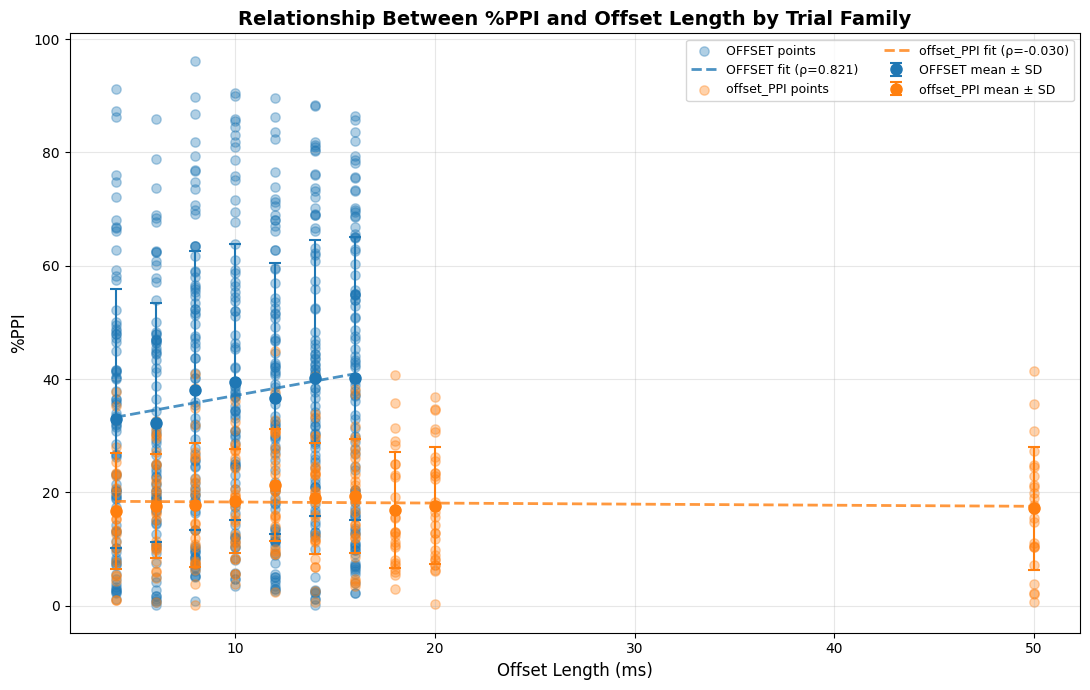

In [ ]:
# Check if %PPI increases with offset length, split by trial family
# Families: OFFSET, offset_PPI, TIN

# Keep trials of interest
offset_trials = ppi_df[ppi_df['Trial'].str.contains('OFFSET|offset_PPI|TIN', case=False, na=False, regex=True)].copy()

# Label trial family
offset_trials['Trial_Type'] = np.select(
    [
        offset_trials['Trial'].str.contains('offset_PPI', case=False, na=False),
        offset_trials['Trial'].str.contains('TIN', case=False, na=False),
        offset_trials['Trial'].str.contains('OFFSET', case=False, na=False)
    ],
    ['offset_PPI', 'TIN', 'OFFSET'],
    default='Other'
 )

# Extract numeric offset length (e.g., OFFSET_10, offset_PPI_10, TIN_10)
offset_trials['Offset_Length'] = offset_trials['Trial'].str.extract(
    r'(?:OFFSET|offset_PPI|TIN)[_\s]*(\d+)', flags=re.IGNORECASE
 )[0].astype(float)

# Remove rows without numeric offset (e.g., TIN_old)
offset_trials = offset_trials.dropna(subset=['Offset_Length'])

if len(offset_trials) > 0:
    print("\n\n%PPI vs. Offset Length (separate by trial family):")
    print("=" * 80)

    trial_order = ['OFFSET', 'offset_PPI', 'TIN']
    color_map = {'OFFSET': 'tab:blue', 'offset_PPI': 'tab:orange', 'TIN': 'tab:green'}

    # Store summaries for plotting
    summaries = {}
    test_results = {}

    for trial_type in trial_order:
        trial_data = offset_trials[offset_trials['Trial_Type'] == trial_type].copy()
        if len(trial_data) == 0:
            continue

        summary = trial_data.groupby('Offset_Length')['%PPI'].agg(['mean', 'std', 'count']).sort_index().reset_index()
        summaries[trial_type] = summary

        print(f"\n{trial_type}:")
        print("-" * 60)
        print(f"{'Offset Length (ms)':<20} {'Mean %PPI':<15} {'Std Dev':<15} {'N':<10}")
        print("-" * 60)
        for row in summary.itertuples(index=False):
            print(f"{int(row.Offset_Length):<20} {row.mean:>14.2f} {row.std:>14.2f} {int(row.count):>9}")

        # Spearman correlation on mean %PPI by offset length
        if len(summary) >= 2 and summary['Offset_Length'].nunique() >= 2:
            corr, p_val = spearmanr(summary['Offset_Length'], summary['mean'])
            test_results[trial_type] = (corr, p_val)
            print(f"Spearman Correlation: {corr:.4f}")
            print(f"P-value: {p_val:.4f}")

            if p_val < 0.05:
                if corr > 0:
                    print("✓ %PPI SIGNIFICANTLY INCREASES with offset length")
                else:
                    print("✓ %PPI SIGNIFICANTLY DECREASES with offset length")
            else:
                print("✗ No significant relationship between %PPI and offset length")
        else:
            test_results[trial_type] = (np.nan, np.nan)
            print("Spearman test not run (need at least 2 offset lengths).")

    # Plot with separate colors per family
    plt.figure(figsize=(11, 7))

    for trial_type in trial_order:
        if trial_type not in summaries:
            continue

        trial_data = offset_trials[offset_trials['Trial_Type'] == trial_type]
        summary = summaries[trial_type]
        color = color_map[trial_type]

        # Individual points
        plt.scatter(
            trial_data['Offset_Length'],
            trial_data['%PPI'],
            alpha=0.35, color=color, s=45, label=f'{trial_type} points', zorder=1
        )

        # Mean ± SD
        plt.errorbar(
            summary['Offset_Length'],
            summary['mean'],
            yerr=summary['std'],
            fmt='o', color=color, markersize=8, capsize=4, capthick=1.5,
            label=f'{trial_type} mean ± SD', zorder=3
        )

        # Linear fit line
        if len(summary) >= 2 and summary['Offset_Length'].nunique() >= 2:
            p = Polynomial.fit(summary['Offset_Length'], summary['mean'], 1)
            x_line = np.linspace(summary['Offset_Length'].min(), summary['Offset_Length'].max(), 100)
            y_line = p(x_line)
            rho, _ = test_results[trial_type]
            plt.plot(
                x_line, y_line, '--', color=color, linewidth=2, alpha=0.8,
                label=f'{trial_type} fit (ρ={rho:.3f})', zorder=2
            )

    plt.xlabel('Offset Length (ms)', fontsize=12)
    plt.ylabel('%PPI', fontsize=12)
    plt.title('Relationship Between %PPI and Offset Length by Trial Family', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()

else:
    print("\nNo OFFSET/offset_PPI/TIN trials with numeric lengths found in the data.")